# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [53]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/data/home_tasks/House_Rent_Dataset (1).csv', sep=None, engine='python')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
# Розмір датасету
df.shape

(4746, 12)

In [55]:
# Перші 5 рядків
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,18.05.2022,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,13.05.2022,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,16.05.2022,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,04.07.2022,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,09.05.2022,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [57]:
 # Загальна інформація про дані (включно з типами даних та кількістю значень)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [58]:
# Пропущені значення і їх відсоток в кожній з колонок
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent


,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


Пропущені значення відсутні, додаткової обробки дані не потребують.

In [59]:
df.describe().round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [60]:
# Аналіз цільової змінної
fig = px.histogram(df, x='Rent', nbins=50, title='Distribution of Rent')
fig.show()


На цьому графіку видно, що хвіст дуже скошений вправо.Більшість квартир мають невисоку орендну плату, але є поодинокі дуже дорогі варіанти, скоріш за все це є викиди.

In [61]:
# Робота з викидами
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df
df_clean = remove_outliers(df, 'Rent')

In [62]:
print("Було:", df.shape[0])
print("Стало:", df_clean.shape[0])
print("Видалено:", df.shape[0] - df_clean.shape[0])

Було: 4746
Стало: 4226
Видалено: 520


In [63]:
# Кількість унікальних значень для кожної з категоріальних колонок.
categorical_columns = df.select_dtypes(include='object').columns

df[categorical_columns].nunique()

,0
Posted On,81
Floor,480
Area Type,3
Area Locality,2235
City,6
Furnishing Status,3
Tenant Preferred,3
Point of Contact,3


Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)**
Що потрібно зробити:

Обчисліть матрицю кореляцій для числових змінних
Візуалізуйте кореляційну матрицю за допомогою heatmap
Побудуйте scatter plot між Size та Rent
Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)

In [64]:
# Матриця кореляції для числових змінних
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,BHK,Rent,Size,Bathroom
BHK,1.000000,0.369718,0.716145,0.794885
Rent,0.369718,1.000000,0.413551,0.441215
Size,0.716145,0.413551,1.000000,0.740703
Bathroom,0.794885,0.441215,0.740703,1.000000


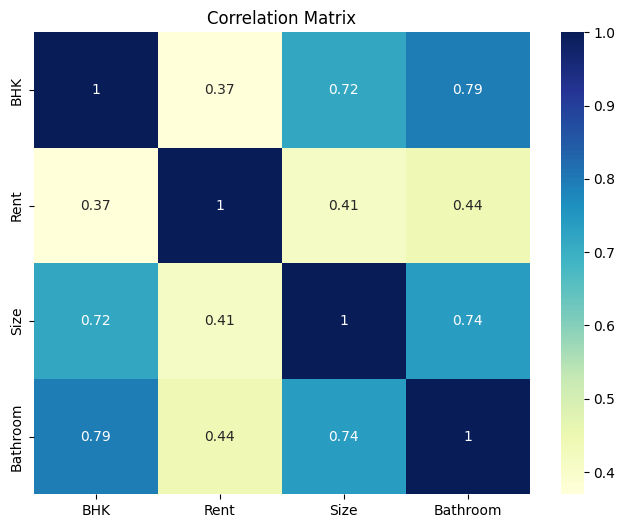

In [65]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.show()



З кореляційної матриці видно, що цільова змінна Rent має помірну позитивну кореляцію з BHK, Size та Bathroom.


In [66]:
fig = px.scatter(
    df_clean,
    x='Size',
    y='Rent',
    opacity=0.5,
    title='Size vs Rent'
)

fig.show()


Між Size та Rent спостерігається позитивна залежність, однак присутній значний розкид, видно, що він зростає із зростом орендної плати.

In [67]:
fig = px.box(
    df_clean,
    x='BHK',
    y='Rent',
    title='Rent distribution by BHK'
)

fig.show()

Boxplot показує, що зі збільшенням кількості BHK загалом зростає медіанна орендна плата.



## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [122]:
# One-Hot Encoding
cols_to_encode = ['City', 'Furnishing Status', 'Tenant Preferred']

df_encoded = pd.get_dummies(
    df_clean,
    columns=cols_to_encode,
    drop_first=True
)

In [123]:
#  Видалення непотрібних колонок
df_encoded = df_encoded.drop(columns=['Area Locality'])

In [124]:
# Формування X і y
X = df_encoded.drop(columns=['Rent'])
y = df_encoded['Rent']


In [125]:
# Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [126]:
# Стандартизація
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [103]:
df_clean = df_clean.drop(columns=['Posted On'])


KeyError: "['Posted On'] not found in axis"

In [104]:
X = df_encoded.drop(columns=['Rent', 'Posted On'], errors='ignore')
y = df_encoded['Rent']

In [105]:
from sklearn.model_selection import train_test_split

# Поділ даних на навчання і тест (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [106]:
from sklearn.linear_model import LinearRegression

In [108]:
model.fit(X_train, y_train)

LinearRegression()

In [109]:
# Коєфіцієнт моделі
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)

coefficients.head(10)

,Feature,Coefficient
9,City_Mumbai,18563.566364
15,Point of Contact_Contact Owner,-8636.843235
14,Point of Contact_Contact Builder,-5811.849032
11,Furnishing Status_Unfurnished,-4544.096964
0,BHK,3521.854280
10,Furnishing Status_Semi-Furnished,-3404.967647
8,City_Kolkata,-3252.281946
2,Bathroom,2550.441555
4,Area Type_Super Area,-2528.141688
7,City_Hyderabad,-2442.211277


In [110]:
# Прогнози на тренувальній та тестовій вибірках
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [111]:
coefficients.head(2)

,Feature,Coefficient
9,City_Mumbai,18563.566364
15,Point of Contact_Contact Owner,-8636.843235


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [112]:
# Обчислюємо MAE, RMSE, R2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Для тренувальної вибірки (Train)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Для тестової вибірки (Test)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("TRAIN:")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

print("\nTEST:")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

TRAIN:
MAE: 5543.609584774834
RMSE: 7694.990169461041
R2: 0.6898465947273125

TEST:
MAE: 5534.118779500578
RMSE: 7729.84039802357
R2: 0.6883802808648167


Значення метрик на тренувальній і тестовій вибірках є дуже близькими, що свідчить про стабільну роботу моделі та відсутність значного перенавчання. Модель демонструє помірну пояснювальну здатність (R² ≈ 0.69), однак рівень помилки залишається досить високим, що може вказувати на обмежену якість ознак або потребу в покращенні моделі.

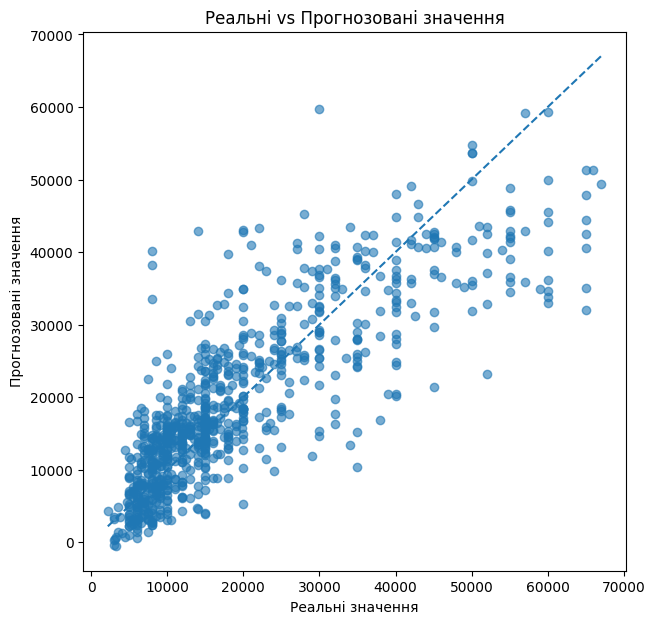

In [114]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_test_pred, alpha=0.6)

# ідеальна лінія
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Реальні значення")
plt.ylabel("Прогнозовані значення")
plt.title("Реальні vs Прогнозовані значення")
plt.show()

Спостерігається значний розкид точок відносно ідеальної лінії, особливо для крайніх значень.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [116]:
# Обчислюємо помилки
residuals = y_test - y_test_pred

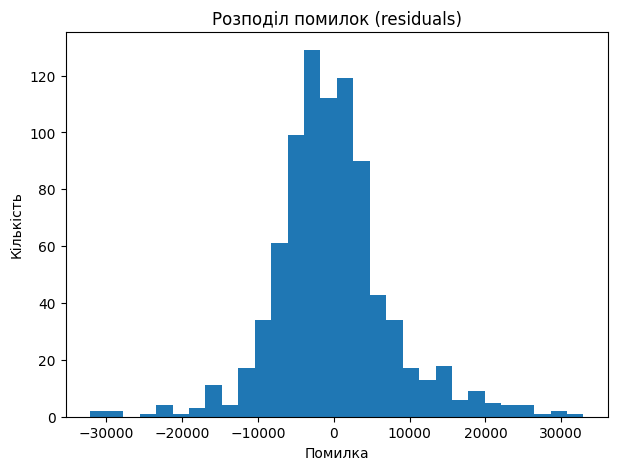

In [117]:
# Гістограма розподілу помилок
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30)
plt.title("Розподіл помилок (residuals)")
plt.xlabel("Помилка")
plt.ylabel("Кількість")
plt.show()

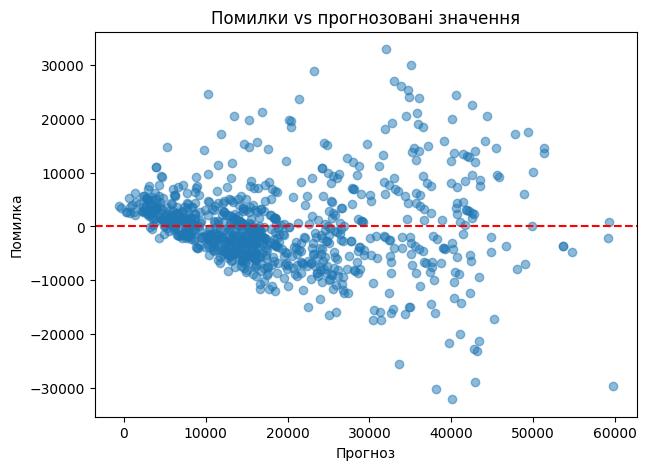

In [118]:
# Scatter plot: помилки vs прогнозовані значення
plt.figure(figsize=(7,5))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')

plt.title("Помилки vs прогнозовані значення")
plt.xlabel("Прогноз")
plt.ylabel("Помилка")
plt.show()

In [119]:
# 5 прогнозів з найбільшими помилками
errors_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred,
    "error": residuals,
    "abs_error": abs(residuals)
})

top_errors = errors_df.sort_values("abs_error", ascending=False).head(5)
top_errors

,y_true,y_pred,error,abs_error
3962,65000,32069.914461,32930.085539,32930.085539
549,8000,40102.178711,-32102.178711,32102.178711
904,8000,38166.196879,-30166.196879,30166.196879
3520,65000,35084.310228,29915.689772,29915.689772
275,30000,59705.850521,-29705.850521,29705.850521
